<a href="https://colab.research.google.com/github/SwapnilJain0308/f1-stratergy-predictor/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install fastf1 pandas matplotlib plotly

In [13]:
import os
os.makedirs('/content/f1_cache_v2', exist_ok=True)

In [14]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt

fastf1.Cache.enable_cache('/content/f1_cache_v2')
session = fastf1.get_session(2023, 'Monaco', 'R')
session.load()
laps = session.laps
print(laps.shape)

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           

(1515, 31)


In [15]:
from google.colab import drive
drive.mount('/content/drive')
laps.to_csv('/content/drive/MyDrive/monaco_2023_laps.csv', index=False)
print("Saved!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved!


In [16]:
top5=laps['Driver'].unique()[:5]
print(top5)


['VER' 'GAS' 'PER' 'ALO' 'LEC']


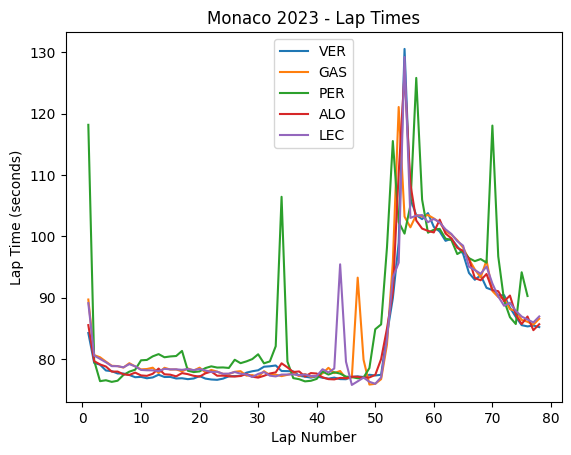

In [17]:
import matplotlib.pyplot as plt
for driver in top5:
  driver_laps=laps[laps['Driver']==driver]
  plt.plot(driver_laps['LapNumber'],
             driver_laps['LapTime'].dt.total_seconds(),
             label=driver)

plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('Monaco 2023 - Lap Times')
plt.legend()
plt.show()

In [18]:
ver_laps = laps[laps['Driver'] == 'VER']
compounds = ver_laps['Compound'].unique()
print(compounds)

['MEDIUM' 'INTERMEDIATE']


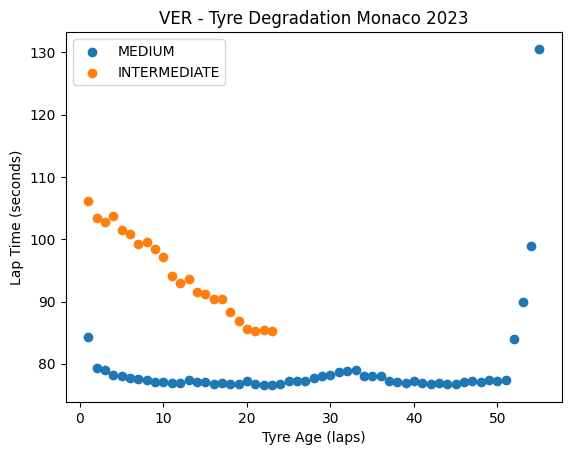

In [19]:
for compound in compounds:
    compound_laps = ver_laps[ver_laps['Compound'] == compound]
    plt.scatter(compound_laps['TyreLife'],
                compound_laps['LapTime'].dt.total_seconds(),
                label=compound)

plt.xlabel('Tyre Age (laps)')
plt.ylabel('Lap Time (seconds)')
plt.title('VER - Tyre Degradation Monaco 2023')
plt.legend()
plt.show()

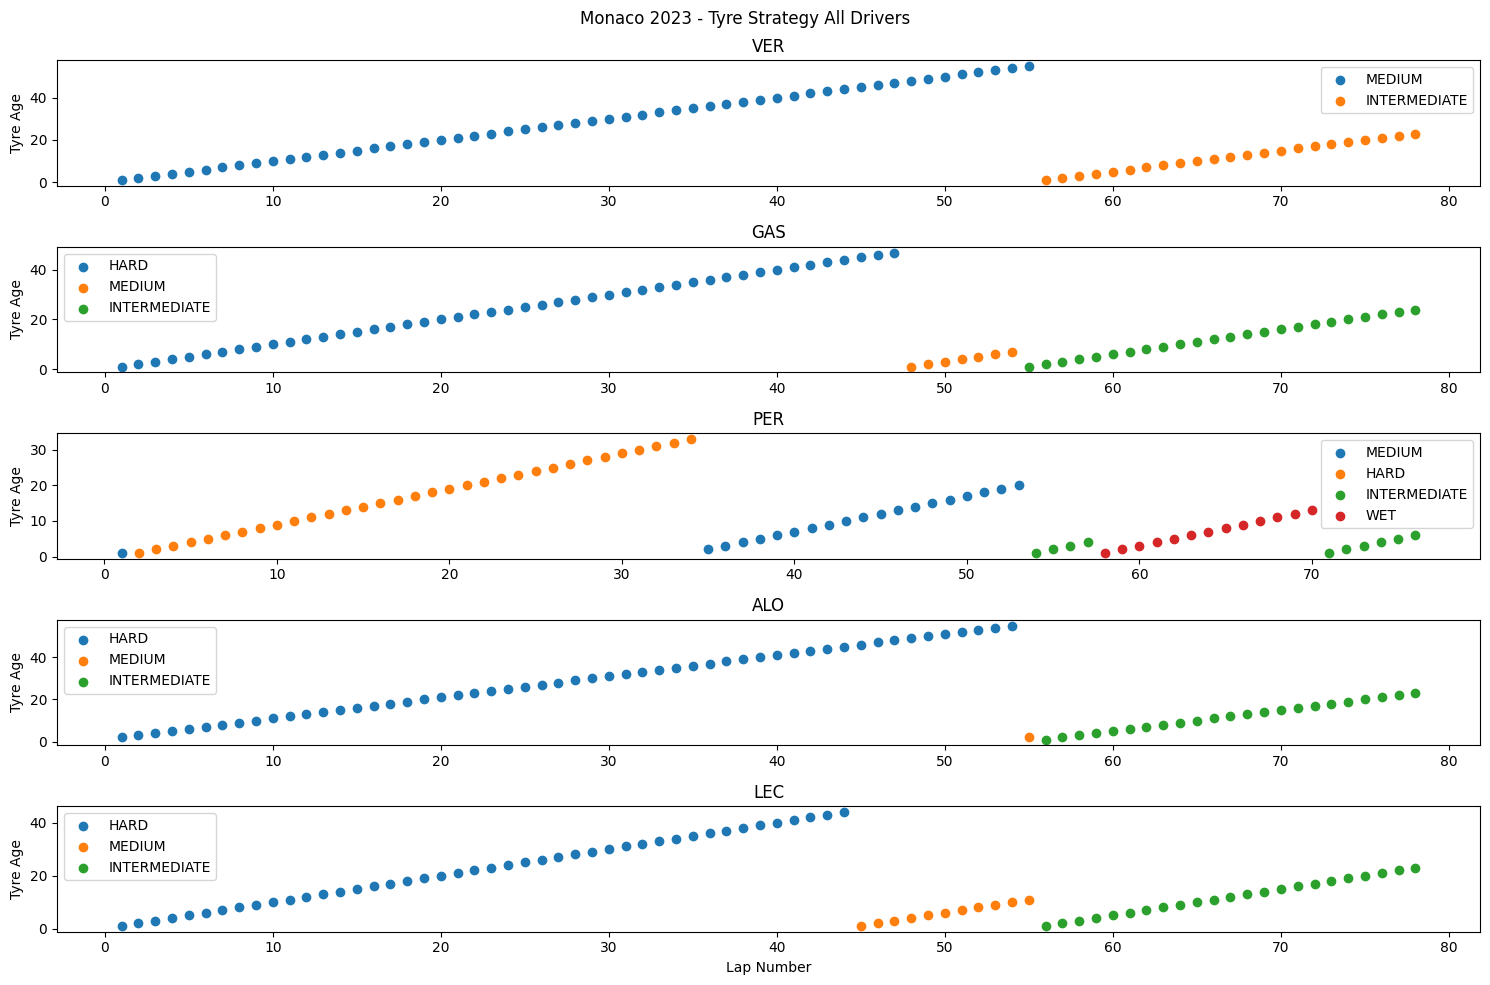

In [20]:
fig, axes = plt.subplots(5, 1, figsize=(15, 10))

for i, driver in enumerate(top5):
    driver_laps = laps[laps['Driver'] == driver]

    for compound in driver_laps['Compound'].unique():
        compound_laps = driver_laps[driver_laps['Compound'] == compound]
        axes[i].scatter(compound_laps['LapNumber'],
                       compound_laps['TyreLife'],
                       label=compound)

    axes[i].set_title(driver)
    axes[i].set_ylabel('Tyre Age')
    axes[i].legend()

axes[-1].set_xlabel('Lap Number')
plt.suptitle('Monaco 2023 - Tyre Strategy All Drivers')
plt.tight_layout()
plt.show()

In [23]:
laps = laps.sort_values(['Driver', 'LapNumber']).reset_index(drop=True)

laps['WillPit'] = 0

for driver in laps['Driver'].unique():
    driver_idx = laps[laps['Driver'] == driver].index
    pit_laps = laps.loc[driver_idx][laps.loc[driver_idx]['PitInTime'].notna()].index

    for pit_idx in pit_laps:
        for i in range(1, 4):
            if pit_idx - i in driver_idx:
                laps.loc[pit_idx - i, 'WillPit'] = 1

print(laps['WillPit'].value_counts())

WillPit
0    1412
1     103
Name: count, dtype: int64


## Note on Data Scope

Visualizations in Week 1 used 5 drivers (VER, GAS, PER, ALO, LEC)
for readability. The full dataset contains all 20 drivers (1515 laps).

Feature engineering and model training uses all 20 drivers
for better generalization.

In [24]:
features = laps[['Driver', 'LapNumber', 'TyreLife', 'Compound', 'Position']].copy()
features['WillPit'] = laps['WillPit']

print(features.head())
print(features.shape)

  Driver  LapNumber  TyreLife Compound  Position  WillPit
0    ALB        1.0       1.0   MEDIUM      13.0        0
1    ALB        2.0       2.0   MEDIUM      13.0        0
2    ALB        3.0       3.0   MEDIUM      13.0        0
3    ALB        4.0       4.0   MEDIUM      13.0        0
4    ALB        5.0       5.0   MEDIUM      13.0        0
(1515, 6)


In [26]:
compound_mapping = {
    'SOFT': 0,
    'MEDIUM': 1,
    'HARD': 2,
    'INTERMEDIATE': 3,
    'WET': 4
}

features['Compound'] = features['Compound'].map(compound_mapping)
print(features.head(10))
print(features['Compound'].value_counts())

  Driver  LapNumber  TyreLife  Compound  Position  WillPit
0    ALB        1.0       1.0         1      13.0        0
1    ALB        2.0       2.0         1      13.0        0
2    ALB        3.0       3.0         1      13.0        0
3    ALB        4.0       4.0         1      13.0        0
4    ALB        5.0       5.0         1      13.0        0
5    ALB        6.0       6.0         1      13.0        0
6    ALB        7.0       7.0         1      13.0        0
7    ALB        8.0       8.0         1      13.0        0
8    ALB        9.0       9.0         1      13.0        0
9    ALB       10.0      10.0         1      13.0        0
Compound
2    667
3    399
1    374
4     45
0     30
Name: count, dtype: int64


In [27]:
driver_mapping = {driver: i for i, driver in enumerate(laps['Driver'].unique())}
features['Driver'] = features['Driver'].map(driver_mapping)
print(features.head())
print(features['Driver'].value_counts())

   Driver  LapNumber  TyreLife  Compound  Position  WillPit
0       0        1.0       1.0         1      13.0        0
1       0        2.0       2.0         1      13.0        0
2       0        3.0       3.0         1      13.0        0
3       0        4.0       4.0         1      13.0        0
4       0        5.0       5.0         1      13.0        0
Driver
1     78
7     78
5     78
4     78
14    78
18    78
13    78
10    78
3     77
2     77
0     77
9     77
19    77
12    77
6     76
11    76
17    76
15    76
8     71
16    54
Name: count, dtype: int64


In [29]:
features = features.dropna()
print(features.shape)
print(features.isnull().sum())

(1514, 6)
Driver       0
LapNumber    0
TyreLife     0
Compound     0
Position     0
WillPit      0
dtype: int64


In [30]:
print(features.isnull().sum())

Driver       0
LapNumber    0
TyreLife     0
Compound     0
Position     0
WillPit      0
dtype: int64


In [31]:
driver_mapping = {driver: i for i, driver in enumerate(laps['Driver'].unique())}
print(driver_mapping)

{'ALB': 0, 'ALO': 1, 'BOT': 2, 'DEV': 3, 'GAS': 4, 'HAM': 5, 'HUL': 6, 'LEC': 7, 'MAG': 8, 'NOR': 9, 'OCO': 10, 'PER': 11, 'PIA': 12, 'RUS': 13, 'SAI': 14, 'SAR': 15, 'STR': 16, 'TSU': 17, 'VER': 18, 'ZHO': 19}


In [32]:
session2 = fastf1.get_session(2023, 'Bahrain', 'R')
session2.load(laps=True, telemetry=False, weather=False, messages=False)
laps2 = session2.laps
print(laps2.shape)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
logger      WARNING 	Failed to load result data from Ergast!
DEBUG:fastf1.fastf1.core:Traceback for failure in ergast result data
Traceback (most r

(1056, 31)


In [33]:
laps2.to_csv('/content/drive/MyDrive/bahrain_2023_laps.csv', index=False)
print("Saved!")

Saved!


In [34]:
session3 = fastf1.get_session(2023, 'Silverstone', 'R')
session3.load(laps=True, telemetry=False, weather=False, messages=False)
laps3 = session3.laps
print(laps3.shape)

core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
logger      WARNING 	Failed to load result data from Ergast!
DEBUG:fastf1.fastf1.core:Traceback for failure in ergast result data
Traceback (most r

(971, 31)


In [35]:
laps3.to_csv('/content/drive/MyDrive/silverstone_2023_laps.csv', index=False)
print("Saved!")

Saved!


In [36]:
session4 = fastf1.get_session(2023, 'Monza', 'R')
session4.load(laps=True, telemetry=False, weather=False, messages=False)
laps4 = session4.laps
print(laps4.shape)

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
logger      WARNING 	Failed to load result data from Ergast!
DEBUG:fastf1.fastf1.core:Traceback for failure in ergast result data
Traceback (most r

(958, 31)


In [37]:
laps4.to_csv('/content/drive/MyDrive/monza_2023_laps.csv', index=False)
print("Saved!")

Saved!


In [38]:
session5 = fastf1.get_session(2023, 'Abu Dhabi', 'R')
session5.load(laps=True, telemetry=False, weather=False, messages=False)
laps5 = session5.laps
print(laps5.shape)

core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Abu Dhabi Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
logger      WARNING 	Failed to load result data from Ergast!
DEBUG:fastf1.fastf1.core:Traceback for failure in ergast result data
Traceback (mo

(1157, 31)


In [39]:
laps5.to_csv('/content/drive/MyDrive/abu_dhabi_2023_laps.csv', index=False)
print("Saved!")

Saved!


In [45]:
import pandas as pd

monaco = pd.read_csv('/content/drive/MyDrive/monaco_2023_laps.csv')
bahrain = pd.read_csv('/content/drive/MyDrive/bahrain_2023_laps.csv')
silverstone = pd.read_csv('/content/drive/MyDrive/silverstone_2023_laps.csv')
monza = pd.read_csv('/content/drive/MyDrive/monza_2023_laps.csv')
abu_dhabi = pd.read_csv('/content/drive/MyDrive/abu_dhabi_2023_laps.csv')

monaco['Race'] = 'Monaco'
bahrain['Race'] = 'Bahrain'
silverstone['Race'] = 'Silverstone'
monza['Race'] = 'Monza'
abu_dhabi['Race'] = 'Abu Dhabi'


all_laps = pd.concat([monaco, bahrain, silverstone, monza, abu_dhabi])
all_laps = all_laps.reset_index(drop=True)

print(all_laps.shape)
print(all_laps['Race'].value_counts())

(5657, 32)
Race
Monaco         1515
Abu Dhabi      1157
Bahrain        1056
Silverstone     971
Monza           958
Name: count, dtype: int64


In [42]:
all_laps.to_csv('/content/drive/MyDrive/all_races_2023_laps.csv', index=False)
print("Saved!")

Saved!


In [43]:
all_laps = all_laps.sort_values(['Race', 'Driver', 'LapNumber']).reset_index(drop=True)

all_laps['WillPit'] = 0

for race in all_laps['Race'].unique():
    for driver in all_laps[all_laps['Race'] == race]['Driver'].unique():
        idx = all_laps[(all_laps['Race'] == race) & (all_laps['Driver'] == driver)].index
        pit_laps = all_laps.loc[idx][all_laps.loc[idx]['PitInTime'].notna()].index

        for pit_idx in pit_laps:
            for i in range(1, 4):
                if pit_idx - i in idx:
                    all_laps.loc[pit_idx - i, 'WillPit'] = 1

print(all_laps['WillPit'].value_counts())

WillPit
0    5130
1     527
Name: count, dtype: int64


In [44]:
features = all_laps[['Driver', 'LapNumber', 'TyreLife', 'Compound', 'Position', 'Race']].copy()
features['WillPit'] = all_laps['WillPit']


compound_mapping = {
    'SOFT': 0, 'MEDIUM': 1, 'HARD': 2,
    'INTERMEDIATE': 3, 'WET': 4
}
features['Compound'] = features['Compound'].map(compound_mapping)


driver_mapping = {driver: i for i, driver in enumerate(all_laps['Driver'].unique())}
features['Driver'] = features['Driver'].map(driver_mapping)


race_mapping = {race: i for i, race in enumerate(all_laps['Race'].unique())}
features['Race'] = features['Race'].map(race_mapping)

features = features.dropna()

print(features.shape)
print(features.head())

(5644, 7)
   Driver  LapNumber  TyreLife  Compound  Position  Race  WillPit
0       0        1.0       2.0         1      17.0     0        0
1       0        2.0       3.0         1      18.0     0        0
2       0        3.0       4.0         1      18.0     0        0
3       0        4.0       5.0         1      18.0     0        0
4       0        5.0       6.0         1      18.0     0        0


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X = features.drop('WillPit', axis=1)
y = features['WillPit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("Confusion Matrix:")
print(cm)


Accuracy: 0.9043401240035429
Confusion Matrix:
[[1021    1]
 [ 107    0]]


In [52]:
!pip install xgboost

In [53]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=5130/527,
    random_state=42
)

xgb_model.fit(X_train, y_train)


y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8724534986713907

Confusion Matrix:
[[901 121]
 [ 23  84]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93      1022
           1       0.41      0.79      0.54       107

    accuracy                           0.87      1129
   macro avg       0.69      0.83      0.73      1129
weighted avg       0.92      0.87      0.89      1129



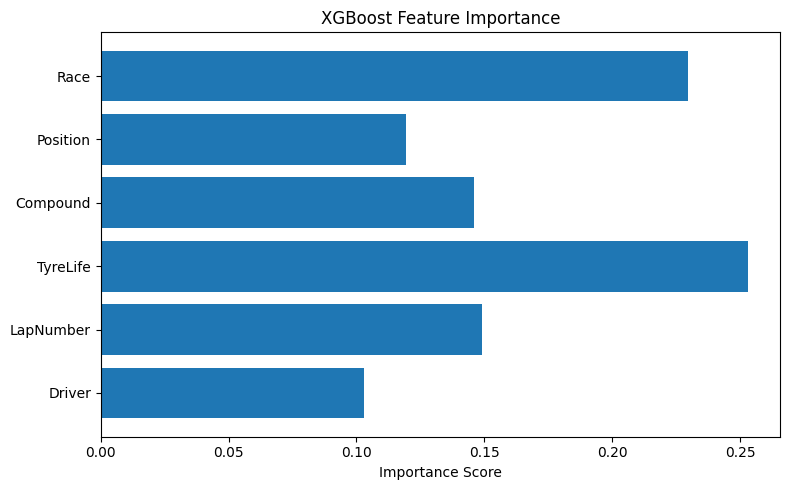

In [54]:
import matplotlib.pyplot as plt

importance = xgb_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8, 5))
plt.barh(feature_names, importance)
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

In [55]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='f1')

print("Cross Validation F1 Scores:", cv_scores)
print("Mean F1 Score:", cv_scores.mean())
print("Std:", cv_scores.std())

Cross Validation F1 Scores: [0.32363636 0.24967825 0.16563147 0.25714286 0.2923588 ]
Mean F1 Score: 0.25768954888469553
Std: 0.05308504366355556


In [56]:
xgb_model_tuned = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=5130/527,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model_tuned.fit(X_train, y_train)
y_pred_tuned = xgb_model_tuned.predict(X_test)

print("Tuned XGBoost Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Tuned XGBoost Accuracy: 0.8972542072630647

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      1022
           1       0.47      0.79      0.59       107

    accuracy                           0.90      1129
   macro avg       0.73      0.85      0.77      1129
weighted avg       0.93      0.90      0.91      1129

